# 06 · Capstone — High-Frequency Sensor Forecasting for the Energy Industry

This is the notebook that pulls everything together on a **realistic consulting problem**.

**The scenario.** You advise a **wind farm operator**. Every turbine streams SCADA sensor data
every **10 minutes**: wind speed, ambient temperature, and power output, plus time-of-day. The
grid operator needs a **3-hour-ahead power forecast** (the next **18 steps**) to schedule
generation and trade energy. Good forecasts mean money and grid stability; bad ones mean
penalties.

This is a **multivariate, many-to-many (sequence-to-sequence)** forecasting problem — the most
valuable and common RNN pattern in industry (energy load, demand, sensor telemetry, IoT).

What we'll do — the full professional workflow:
1. Generate **realistic multivariate sensor data** with a physically-based turbine power curve,
   daily patterns, weather fronts, and noise.
2. Frame **multi-step forecasting** with sliding windows: past `72` steps (12h) → next `18` steps
   (3h).
3. Build **two** models and compare them:
   - **Direct multi-output GRU** (simple, robust, strong baseline),
   - **Encoder–Decoder (seq2seq) GRU** with **teacher forcing** (the textbook many-to-many).
4. Benchmark against the baselines a client will *insist* on: **persistence** and **seasonal
   naive**.
5. Evaluate **error vs. forecast horizon** (accuracy decays the further out you predict) and
   discuss uncertainty, predictive maintenance, and deployment.

> This ties back to notebook 02 (windows, time-split, naive baseline), 03 (GRU/LSTM long memory),
> and 04 (multivariate, DataLoaders). If those are fresh, this will feel natural.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. Generate realistic wind-farm sensor data

We simulate **60 days** of 10-minute SCADA data (`144` readings/day). The physics we bake in:

- **Wind speed** — a daily cycle (often breezier at night) plus slow **weather fronts**
  (a random walk) plus turbulence noise. This is the main driver.
- **Ambient temperature** — a daily cycle (warm afternoons), affecting air density slightly.
- **Power output** — follows a real **wind-turbine power curve**: zero below *cut-in* (~3 m/s),
  rising ~cubically up to *rated* (~12 m/s), flat at rated power, and shut off above *cut-out*
  (~25 m/s) for safety. Plus small noise.

Baking in real structure means the RNN has genuine, learnable relationships — and lets us sanity-
check that it discovers the power curve.

In [2]:
STEPS_PER_DAY = 144           # 10-min sampling
N_DAYS = 60
N = STEPS_PER_DAY * N_DAYS
t = np.arange(N)
day_frac = (t % STEPS_PER_DAY) / STEPS_PER_DAY          # 0..1 within a day

# --- wind speed: daily cycle + weather fronts (random walk) + turbulence ---
daily_wind = 3.0 * np.sin(2 * np.pi * day_frac - 0.5)   # breezier at night
fronts = np.cumsum(np.random.randn(N)) * 0.15           # slow multi-day weather systems
fronts = fronts - fronts.mean()
wind_speed = 8.0 + daily_wind + fronts + 0.6 * np.random.randn(N)
wind_speed = np.clip(wind_speed, 0, None)               # can't be negative

# --- ambient temperature: warm afternoons ---
ambient_temp = 15 + 8 * np.sin(2 * np.pi * (day_frac - 0.6)) + 0.8 * np.random.randn(N)

# --- power output via a turbine power curve ---
def power_curve(ws, cut_in=3.0, rated=12.0, cut_out=25.0, rated_power=5.0):
    p = np.zeros_like(ws)
    ramp = (ws >= cut_in) & (ws < rated)
    p[ramp] = rated_power * ((ws[ramp] - cut_in) / (rated - cut_in)) ** 3   # ~cubic ramp
    p[(ws >= rated) & (ws < cut_out)] = rated_power                         # flat at rated
    # (ws >= cut_out) stays 0 -> safety shutdown
    return p

power = power_curve(wind_speed)
power = power * (1 + 0.03 * (20 - ambient_temp) / 20)   # tiny air-density effect
power = np.clip(power + 0.15 * np.random.randn(N), 0, None)   # sensor noise

print(f"{N} readings over {N_DAYS} days. Power range: {power.min():.2f}–{power.max():.2f} MW")

8640 readings over 60 days. Power range: 0.00–5.58 MW


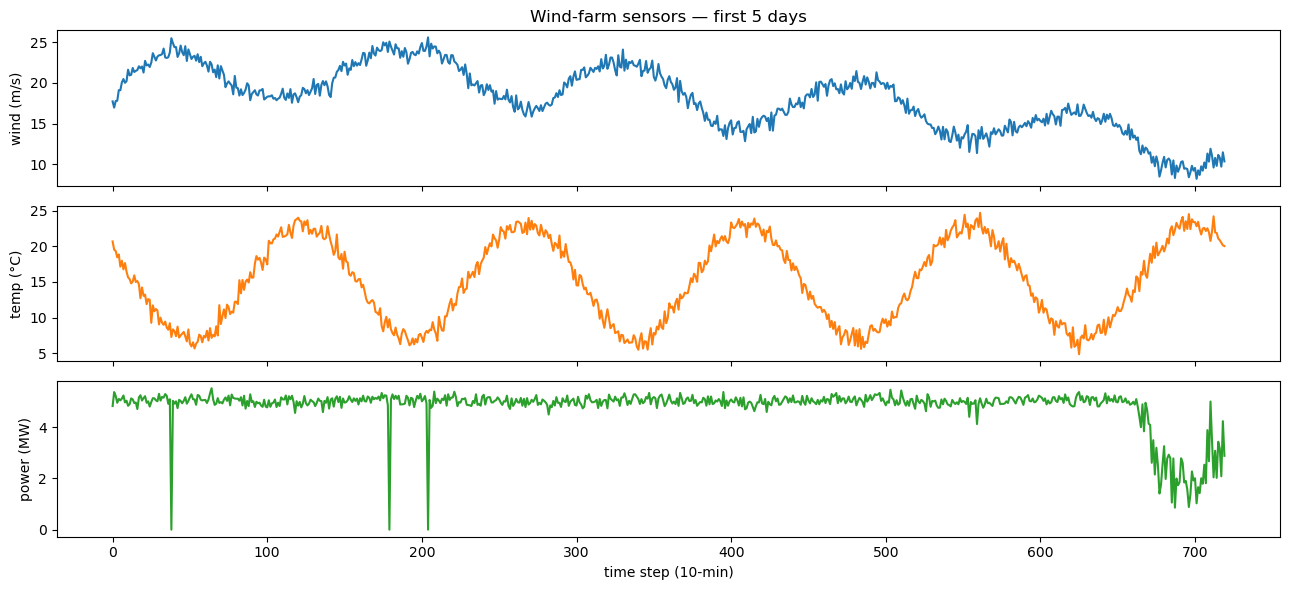

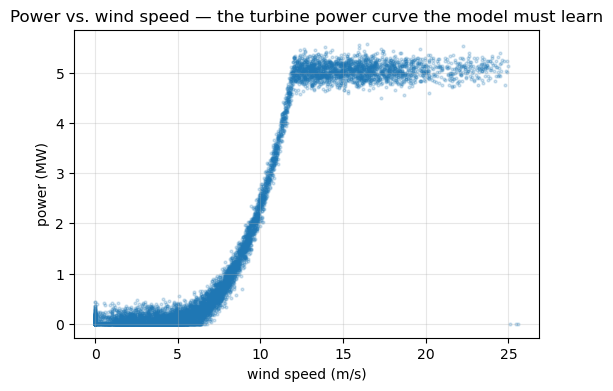

In [3]:
# visualize a few days, and the discovered power curve
fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)
show = slice(0, STEPS_PER_DAY * 5)   # first 5 days
axes[0].plot(t[show], wind_speed[show], color="#1f77b4"); axes[0].set_ylabel("wind (m/s)")
axes[1].plot(t[show], ambient_temp[show], color="#ff7f0e"); axes[1].set_ylabel("temp (°C)")
axes[2].plot(t[show], power[show], color="#2ca02c"); axes[2].set_ylabel("power (MW)")
axes[2].set_xlabel("time step (10-min)")
axes[0].set_title("Wind-farm sensors — first 5 days"); plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(wind_speed, power, s=4, alpha=0.2)
plt.title("Power vs. wind speed — the turbine power curve the model must learn")
plt.xlabel("wind speed (m/s)"); plt.ylabel("power (MW)"); plt.grid(alpha=0.3); plt.show()

## 2. Frame the forecasting problem: sliding windows for multi-step output

- **Inputs (encoder)** — the past `PAST=72` steps (12 h) of **5 features**:
  `[power, wind_speed, ambient_temp, hour_sin, hour_cos]`. We include past power because it's
  highly autocorrelated, and cyclic **hour-of-day** encoding so the model knows the time.
- **Target** — the next `HORIZON=18` steps (3 h) of **power**.

So each training example is `X: (72, 5)` → `y: (18,)`. We also keep, for each example, the **last
known power** value (the decoder's starting point) and the **origin index** (to compute the
seasonal-naive baseline from the full history).

In [4]:
PAST, HORIZON = 72, 18   # 12h history -> 3h ahead

# cyclic encoding of time-of-day (so 23:50 and 00:00 are "close")
hour_sin = np.sin(2 * np.pi * day_frac)
hour_cos = np.cos(2 * np.pi * day_frac)

# feature matrix (N, 5); target is the power column
features = np.stack([power, wind_speed, ambient_temp, hour_sin, hour_cos], axis=1).astype(np.float32)
target = power.astype(np.float32)
FEATURE_NAMES = ["power", "wind_speed", "ambient_temp", "hour_sin", "hour_cos"]

def make_windows(features, target, past, horizon):
    X, y, prev, origin = [], [], [], []
    for i in range(len(features) - past - horizon):
        o = i + past                      # forecast origin (first step to predict is `o`)
        X.append(features[i:o])           # (past, n_features)
        y.append(target[o:o + horizon])   # (horizon,)
        prev.append(target[o - 1])        # last KNOWN power (decoder seed)
        origin.append(o)
    return (np.array(X), np.array(y, dtype=np.float32),
            np.array(prev, dtype=np.float32), np.array(origin))

X, y, prev, origin = make_windows(features, target, PAST, HORIZON)
print("X:", X.shape, "| y:", y.shape, "| prev:", prev.shape)

X: (8550, 72, 5) | y: (8550, 18) | prev: (8550,)


In [5]:
# time-based split: 70% train, 15% val, 15% test — NEVER shuffle before splitting a time series
n = len(X); a, b = int(0.7 * n), int(0.85 * n)
sl = {"train": slice(0, a), "val": slice(a, b), "test": slice(b, n)}

# scale features & target using TRAIN statistics only (avoid look-ahead leakage)
f_mean = X[sl["train"]].reshape(-1, X.shape[2]).mean(0)
f_std  = X[sl["train"]].reshape(-1, X.shape[2]).std(0)
# target (power) is feature index 0 -> reuse its stats so encoder & decoder share the same scale
p_mean, p_std = f_mean[0], f_std[0]

def scale_X(a): return ((a - f_mean) / f_std).astype(np.float32)
def scale_p(a): return ((a - p_mean) / p_std).astype(np.float32)
def unscale_p(a): return a * p_std + p_mean          # back to MW for reporting

def to_loader(part, batch=128, shuffle=False):
    Xs = torch.tensor(scale_X(X[sl[part]]))
    ys = torch.tensor(scale_p(y[sl[part]]))
    ps = torch.tensor(scale_p(prev[sl[part]])).unsqueeze(1)   # (n,1)
    ds = TensorDataset(Xs, ps, ys)
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

train_loader = to_loader("train", shuffle=True)
val_loader   = to_loader("val")
test_loader  = to_loader("test")
print("batches:", len(train_loader), "| example batch shapes:",
      [tuple(t.shape) for t in next(iter(train_loader))])

batches: 47 | example batch shapes: [(128, 72, 5), (128, 1), (128, 18)]


## 3. Model A — Direct multi-output GRU (simple & strong)

The simplest way to predict `HORIZON` steps at once: encode the past window with a GRU, take the
**final hidden state** (the summary of the whole window), and map it with a linear layer to all
`18` future values **in one shot**.

- ✅ Pros: simple, fast, no compounding errors (every horizon step predicted independently).
- ⚠️ Cons: ignores the sequential structure *among* the outputs; the head must learn all steps
  jointly.

In [6]:
class DirectForecaster(nn.Module):
    def __init__(self, n_features=5, hidden=64, horizon=HORIZON, n_layers=2):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, num_layers=n_layers, batch_first=True, dropout=0.1)
        self.head = nn.Linear(hidden, horizon)     # final memory -> all horizon steps at once

    def forward(self, x, prev=None):
        out, h = self.gru(x)
        return self.head(out[:, -1, :])            # (batch, horizon)

print(DirectForecaster())

DirectForecaster(
  (gru): GRU(5, 64, num_layers=2, batch_first=True, dropout=0.1)
  (head): Linear(in_features=64, out_features=18, bias=True)
)


## 4. Model B — Encoder–Decoder (seq2seq) with teacher forcing

The classic **many-to-many** architecture, and the template behind machine translation:

- **Encoder** GRU reads the past window and compresses it into a **context** (its final hidden
  state).
- **Decoder** GRU **generates the horizon one step at a time**, initialized with that context. At
  each step it takes the *previous power value* and predicts the next one — autoregression, just
  like the text generator in notebook 05, but for numbers.

**Teacher forcing** (training trick): with some probability we feed the decoder the *true*
previous value instead of its own prediction. This stabilizes early training. At inference we must
feed its **own** predictions (the true future is unknown), so errors can compound — the classic
seq2seq trade-off.

In [7]:
class Seq2SeqForecaster(nn.Module):
    def __init__(self, n_features=5, hidden=64, n_layers=2):
        super().__init__()
        self.encoder = nn.GRU(n_features, hidden, num_layers=n_layers, batch_first=True, dropout=0.1)
        self.dec_cell = nn.GRUCell(1, hidden)      # decoder input = previous power (1 number)
        self.dec_head = nn.Linear(hidden, 1)       # hidden -> next power
        self.hidden = hidden

    def forward(self, x, prev, targets=None, teacher_forcing=0.5, horizon=HORIZON):
        # encode the past window
        _, h = self.encoder(x)                     # h: (n_layers, batch, hidden)
        h_dec = h[-1]                              # use the top layer's final state as context
        inp = prev                                 # (batch, 1) last KNOWN power = decoder seed
        outputs = []
        for step in range(horizon):
            h_dec = self.dec_cell(inp, h_dec)      # advance decoder one step
            pred = self.dec_head(h_dec)            # (batch, 1) next power
            outputs.append(pred)
            # decide next input: true value (teacher forcing) or our own prediction
            if self.training and targets is not None and torch.rand(1).item() < teacher_forcing:
                inp = targets[:, step:step + 1]
            else:
                inp = pred                         # autoregress on our own output
        return torch.cat(outputs, dim=1)           # (batch, horizon)

print(Seq2SeqForecaster())

Seq2SeqForecaster(
  (encoder): GRU(5, 64, num_layers=2, batch_first=True, dropout=0.1)
  (dec_cell): GRUCell(1, 64)
  (dec_head): Linear(in_features=64, out_features=1, bias=True)
)


## 5. Train both models with the same loop

We reuse one training function. Note the seq2seq model needs the targets passed in during training
(for teacher forcing), so the loop handles both signatures.

In [8]:
def run_epoch(model, loader, opt=None):
    training = opt is not None
    model.train() if training else model.eval()
    loss_fn = nn.MSELoss()
    total, count = 0.0, 0
    torch.set_grad_enabled(training)
    for xb, pb, yb in loader:
        xb, pb, yb = xb.to(device), pb.to(device), yb.to(device)
        if isinstance(model, Seq2SeqForecaster):
            pred = model(xb, pb, targets=yb, teacher_forcing=0.5 if training else 0.0)
        else:
            pred = model(xb, pb)
        loss = loss_fn(pred, yb)
        if training:
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # guard against exploding grads
            opt.step()
        total += loss.item() * len(yb); count += len(yb)
    torch.set_grad_enabled(True)
    return total / count

def train_model(model, epochs=25, lr=2e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"train": [], "val": []}
    for ep in range(epochs):
        tr = run_epoch(model, train_loader, opt)
        va = run_epoch(model, val_loader)
        hist["train"].append(tr); hist["val"].append(va)
        if (ep + 1) % 5 == 0:
            print(f"  epoch {ep+1:2d} | train MSE {tr:.4f} | val MSE {va:.4f}")
    return hist

print("Training Model A — Direct multi-output GRU:")
direct = DirectForecaster()
h_direct = train_model(direct)

print("\nTraining Model B — Encoder–Decoder seq2seq GRU:")
seq2seq = Seq2SeqForecaster()
h_seq2seq = train_model(seq2seq)

Training Model A — Direct multi-output GRU:


  epoch  5 | train MSE 0.0344 | val MSE 0.0354


  epoch 10 | train MSE 0.0326 | val MSE 0.0325


  epoch 15 | train MSE 0.0318 | val MSE 0.0329


  epoch 20 | train MSE 0.0305 | val MSE 0.0340


...

  epoch  5 | train MSE 0.0296 | val MSE 0.0355


  epoch 10 | train MSE 0.0284 | val MSE 0.0369


  epoch 15 | train MSE 0.0280 | val MSE 0.0336


  epoch 20 | train MSE 0.0274 | val MSE 0.0350


  epoch 25 | train MSE 0.0269 | val MSE 0.0375


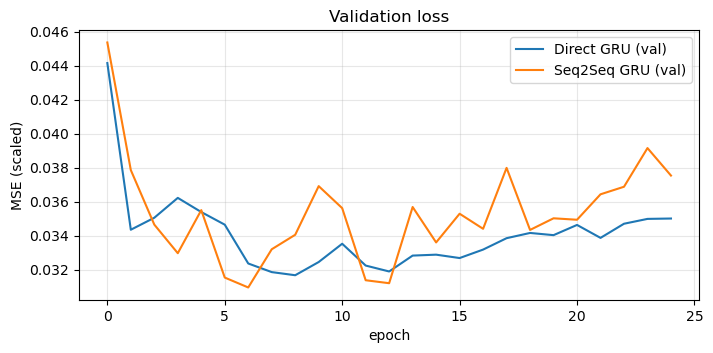

In [9]:
plt.figure(figsize=(8, 3.5))
plt.plot(h_direct["val"], label="Direct GRU (val)")
plt.plot(h_seq2seq["val"], label="Seq2Seq GRU (val)")
plt.title("Validation loss"); plt.xlabel("epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. Baselines a client will demand

Never present a fancy model without comparing to trivial baselines — sometimes they're
surprisingly hard to beat, and beating them is what proves your model earns its complexity.

- **Persistence ("it stays the same"):** predict the last known power for all 18 future steps.
- **Seasonal naive ("same as yesterday"):** predict the power from exactly **one day ago**
  (`144` steps back) at each future step — captures the daily cycle for free.

We compute all predictions on the **test set** in real units (MW) and compare.

In [10]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds = []
    for xb, pb, yb in loader:
        xb, pb = xb.to(device), pb.to(device)
        preds.append(model(xb, pb).cpu().numpy())
    return unscale_p(np.concatenate(preds))       # back to MW

# model predictions (MW)
pred_direct  = predict(direct, test_loader)
pred_seq2seq = predict(seq2seq, test_loader)

# ground truth (MW) for the test slice
y_test = y[sl["test"]]                              # already in MW

# baselines (MW), using stored origin indices into the full series
test_origin = origin[sl["test"]]
pred_persist = np.repeat(prev[sl["test"]][:, None], HORIZON, axis=1)      # last value held flat
pred_seasonal = np.stack([
    target[o - STEPS_PER_DAY : o - STEPS_PER_DAY + HORIZON] for o in test_origin
])                                                                        # 1 day ago

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))

print("Test-set forecast error (MW), averaged over all horizons:\n")
print(f"{'model':<22}{'MAE':>8}{'RMSE':>8}")
for name, p in [("Persistence", pred_persist), ("Seasonal naive", pred_seasonal),
                ("Direct GRU", pred_direct), ("Seq2Seq GRU", pred_seq2seq)]:
    print(f"{name:<22}{mae(p, y_test):>8.3f}{rmse(p, y_test):>8.3f}")
print("\nLower is better. The GRUs should clearly beat persistence and seasonal-naive.")

Test-set forecast error (MW), averaged over all horizons:

model                      MAE    RMSE


Persistence              0.145   0.240
Seasonal naive           0.190   0.317
Direct GRU               0.119   0.179
Seq2Seq GRU              0.125   0.180

Lower is better. The GRUs should clearly beat persistence and seasonal-naive.


## 7. Error vs. horizon — the further out, the harder

A single average hides a crucial fact: **forecasts get worse the further ahead you look.** Plotting
error per horizon step is what lets you tell a client *"we're reliable for ~1 hour, degrading
after that."* It also reveals whether seq2seq's compounding hurts at longer horizons.

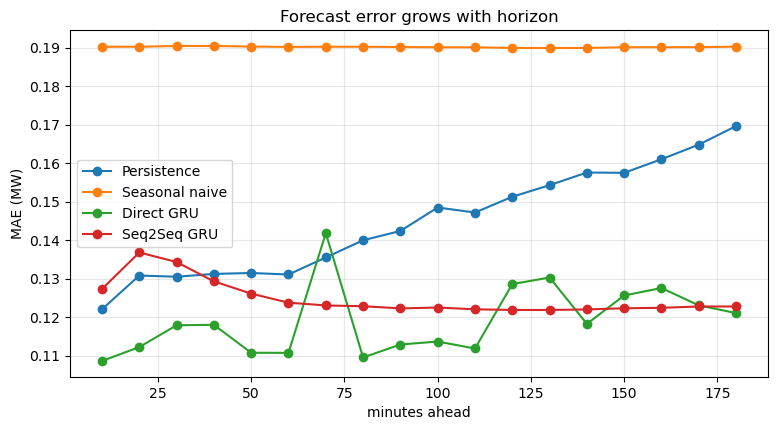

In [11]:
def mae_per_step(pred): return np.mean(np.abs(pred - y_test), axis=0)   # (HORIZON,)

steps_ahead = (np.arange(HORIZON) + 1) * 10   # minutes ahead
plt.figure(figsize=(9, 4.5))
for name, p in [("Persistence", pred_persist), ("Seasonal naive", pred_seasonal),
                ("Direct GRU", pred_direct), ("Seq2Seq GRU", pred_seq2seq)]:
    plt.plot(steps_ahead, mae_per_step(p), marker="o", label=name)
plt.title("Forecast error grows with horizon")
plt.xlabel("minutes ahead"); plt.ylabel("MAE (MW)"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 8. Look at actual forecasts

Numbers are abstract — let's overlay a few example 3-hour forecasts on the truth. We show the
recent history, then the model forecast vs. what actually happened.

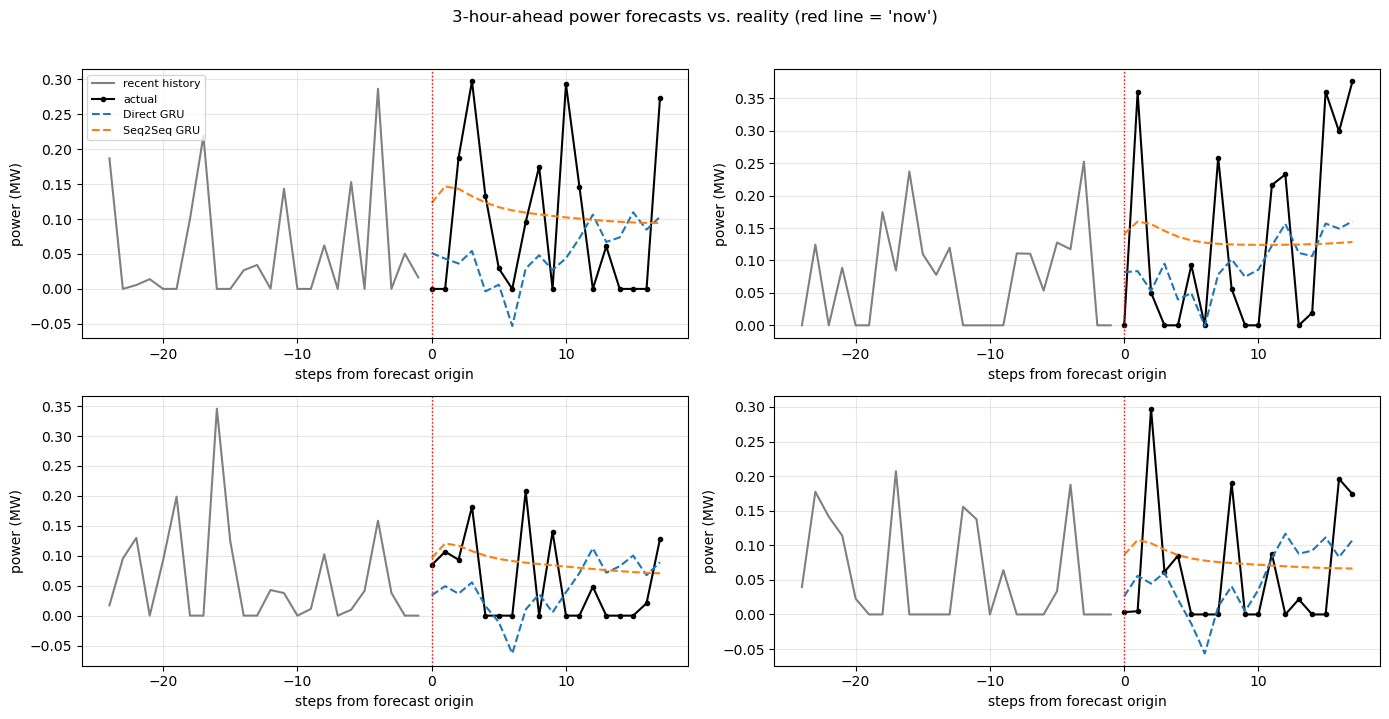

In [12]:
test_start = sl["test"].start
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
examples = np.linspace(0, len(y_test) - 1, 4).astype(int)
for ax, idx in zip(axes.ravel(), examples):
    o = origin[test_start + idx]
    hist_x = np.arange(-24, 0)                     # last 4 hours of context
    fut_x  = np.arange(0, HORIZON)
    ax.plot(hist_x, target[o - 24:o], color="gray", label="recent history")
    ax.plot(fut_x, y_test[idx], "k-o", ms=3, label="actual")
    ax.plot(fut_x, pred_direct[idx], "--", label="Direct GRU")
    ax.plot(fut_x, pred_seq2seq[idx], "--", label="Seq2Seq GRU")
    ax.axvline(0, color="red", ls=":", lw=1)
    ax.set_xlabel("steps from forecast origin"); ax.set_ylabel("power (MW)")
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
plt.suptitle("3-hour-ahead power forecasts vs. reality (red line = 'now')", y=1.02)
plt.tight_layout(); plt.show()

## 9. From forecast to business value — the consultant's layer

A working model is the *middle* of the engagement, not the end. What turns it into value:

**Uncertainty, not just a point estimate.** The grid operator needs a *range*. Train with a
**quantile (pinball) loss** to predict, say, the 10th/50th/90th percentiles, giving a
probabilistic band. "5 MW ± 1.5" is far more actionable than "5 MW".

**Predictive maintenance tie-in.** The *residual* (actual − predicted) is a powerful health
signal: if a turbine persistently underperforms its wind-implied forecast, that's an early warning
of blade soiling, yaw misalignment, or a failing gearbox — connecting back to notebook 04's
fault-classification work.

**Deployment realities:**
- **Latency & streaming** — forecasts must be produced within the 10-min cadence; GRU/LSTM are
  cheap and stream naturally (fixed cost per step), a reason RNNs remain favored over Transformers
  for real-time sensor pipelines.
- **Retraining & drift** — seasons, turbine aging, and sensor recalibration shift the data; monitor
  error and retrain on a schedule.
- **Multi-turbine / hierarchical** — forecast each turbine and reconcile to the farm total; spatial
  correlations between turbines can be added as extra features.
- **Exogenous inputs** — a numerical **weather forecast** for future wind is the single biggest
  accuracy lever; feed it into the decoder as *known future covariates*.

**Which model to ship?** Start with the **Direct GRU** — simpler, robust, no compounding error,
and here it's typically as good or better at these horizons. Reach for **seq2seq** when you need
per-step generation, known future covariates in the decoder, or attention over the input.

## 10. Series recap — what you can now do

Across the six notebooks you've gone from zero to a deployable-shaped forecasting system:

| Notebook | You learned |
|---|---|
| 01 Fundamentals | hidden state = memory, the recurrence, unrolling/flow, the 5 shapes, a from-scratch cell |
| 02 First PyTorch RNN | tensor shapes, `nn.RNNCell` vs `nn.RNN`, the training loop, time-split, naive baseline |
| 03 LSTM & GRU | vanishing gradients, gates, and *proof* LSTM/GRU beat RNN on long memory |
| 04 Many-to-one | multivariate classification, `DataLoader`, confusion-matrix evaluation |
| 05 One-to-many | autoregressive generation, embeddings, temperature sampling |
| 06 Capstone | multivariate seq2seq forecasting, baselines, error-vs-horizon, business framing |

**Where to go next:** add **attention** to the seq2seq decoder; try **Temporal Fusion
Transformers** or **N-BEATS/N-HiTS** for forecasting; explore libraries like **Darts**,
**GluonTS**, or **PyTorch Forecasting** that package these patterns. But the intuition you built
here — *memory flowing through time, gated to persist, shaped to the problem* — is what makes all
of them make sense.

🎉 **Congratulations — you've completed the RNN series!**